# Transfer learning with an EO foundation model for oil spill detection in a data-scarce setting

This tutorial demonstrates how to use a globally pretrained Earth Observation (EO) foundation model to perform image‑level classification on Sentinel‑1 SAR data.

**Problem statement:**  
Given a Sentinel‑1 SAR image in Sigma0 backscatter (VV and VH polarizations), expressed in decibel (dB) units, the task is to determine whether the image:
- contains an oil spill (*class = oil*),
- represents clean water (*class = clean*) or contains an oil look‑alike phenomenon (*class = lookalike*).
  
**Constraint:** We only have about 100 labelled images of each class to start with. This problem domain is known as data-scarce setting or data-limited regime.

**Proposed approach:**  
We build a supervised classifier on top of a pretrained EO foundation model and adapt it to this task by training a lightweight classification head using labeled SAR imagery.

**Model choice:**  
In this tutorial, we use the SATLAS pretrained model from the Allen Institute, which provides globally trained representations for Earth observation data. See the official repository for details on the model architecture, training data, and licensing:
https://github.com/allenai/satlaspretrain_models and https://huggingface.co/allenai/satlas-pretrain

**Dataset:**  
The dataset used in this tutorial is obtained from Zenodo (DOI: 10.5281/zenodo.8346859). Please refer to the original source (https://zenodo.org/records/8346860) for licensing terms and usage restrictions. Note the dataset is larger but I chose a small random subset of the train dataset for the purpose of this tutorial.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import rasterio
from rasterio.transform import xy as rio_xy
import geopandas as gpd
from shapely.geometry import Point

import cv2

import torch
from torch.utils.data import DataLoader

import random
import os
import glob
from pathlib import Path

In [3]:
import OilSpillClassification as oilcls

In [4]:
train_images_dir_oil = r"C:\Users\user\Documents\oilspill\dataset\train\oil"
train_images_dir_look= r"C:\Users\user\Documents\oilspill\dataset\train\lookalike"
train_images_dir_clean = r"C:\Users\user\Documents\oilspill\dataset\train\clean"
train_df = {'images_dir_oil': train_images_dir_oil,
            'images_dir_lookalike': train_images_dir_look,
            'images_dir_clean': train_images_dir_clean}

val_images_dir_oil = r"C:\Users\user\Documents\oilspill\dataset\val\oil"
val_images_dir_look = r"C:\Users\user\Documents\oilspill\dataset\val\lookalike"
val_images_dir_clean = r"C:\Users\user\Documents\oilspill\dataset\val\clean"
val_df = {'images_dir_oil': val_images_dir_oil,
            'images_dir_lookalike': val_images_dir_look,
            'images_dir_clean': val_images_dir_clean}

test_images_dir_oil = r"C:\Users\user\Documents\oilspill\dataset\test\oil"
test_images_dir_look = r"C:\Users\user\Documents\oilspill\dataset\test\lookalike"
test_images_dir_clean = r"C:\Users\user\Documents\oilspill\dataset\test\clean"
test_df = {'images_dir_oil': test_images_dir_oil,
          'images_dir_lookalike': test_images_dir_look,
          'images_dir_clean': test_images_dir_clean}

gpkg_path = r"C:\Users\user\user\oilspill\sar_oil_spill_dataset.gpkg"
device = "cuda" if torch.cuda.is_available() else "cpu"
input_size = 512 # I choose to downsize images but we can experiment with original resolutions (2048 pixels) too.

# Here I choose to merge clean & lookalike classes (binary classification) but we can of course experiment with three classes too.

# Settings for binary classification
class_names = ["clean","oil"]
merge_clean_lookalike = True
num_classes = 2

# # Settings for three-way classification
# class_names = ["clean","oil", "lookalike"]
# merge_clean_lookalike = False
# num_classes = 3

In [5]:
# If you want to reproduce exactly the same experiments as this tutorial, after downloading the part1, part2 and part3 of the datasets from zenodo, choose 
# the following sample files and place then them into folders accordint to the structure printed below.

def print_tree(path, prefix=""):
    path = Path(path)
    tree = []
    contents = sorted(path.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for i, item in enumerate(contents):
        connector = "└── " if i == len(contents) - 1 else "├── "
        tree.append(prefix + connector + item.name)
        if item.is_dir():
            extension = "    " if i == len(contents) - 1 else "│   "
            tree.extend(print_tree(item, prefix + extension))
    return tree

folder = r"C:\Users\user\Documents\oilspill\dataset"
print("\n".join(print_tree(folder)))


├── test
│   ├── clean
│   │   ├── 00000.tif
│   │   ├── 00001.tif
│   │   ├── 00002.tif
│   │   ├── 00003.tif
│   │   ├── 00004.tif
│   │   ├── 00005.tif
│   │   ├── 00006.tif
│   │   ├── 00007.tif
│   │   ├── 00008.tif
│   │   ├── 00009.tif
│   │   ├── 00010.tif
│   │   ├── 00011.tif
│   │   ├── 00012.tif
│   │   ├── 00013.tif
│   │   ├── 00014.tif
│   │   ├── 00015.tif
│   │   ├── 00016.tif
│   │   ├── 00017.tif
│   │   ├── 00018.tif
│   │   ├── 00019.tif
│   │   ├── 00020.tif
│   │   ├── 00021.tif
│   │   ├── 00022.tif
│   │   ├── 00023.tif
│   │   ├── 00024.tif
│   │   ├── 00025.tif
│   │   ├── 00026.tif
│   │   ├── 00027.tif
│   │   ├── 00028.tif
│   │   ├── 00029.tif
│   │   ├── 00030.tif
│   │   ├── 00031.tif
│   │   ├── 00032.tif
│   │   ├── 00033.tif
│   │   ├── 00034.tif
│   │   ├── 00035.tif
│   │   ├── 00036.tif
│   │   ├── 00037.tif
│   │   ├── 00038.tif
│   │   ├── 00039.tif
│   │   ├── 00040.tif
│   │   ├── 00041.tif
│   │   ├── 00042.tif
│   │   ├── 00043.tif
│   │   ├

# Objectives

- Inspect train/val/test distributions and possible mismatches (OOD issues)
- Validate our data normalization strategy
- Check class balance and sampling implications
- Inspect representation quality of pretrained Satlas embeddings
- Decide whether a simple linear classifier built on top of a frozen Satlas encoder is adequate


## Spectral Distributions
What we want to check:
- Peaks roughly aligned? 
- Similar tail behavior? 
- No clipping artifacts?

In [6]:
# subsampling some pixels so plots will not take forever.

no_data_db = 0.0
def read_sample(impath):
    with rasterio.open(impath) as src:
        img = src.read()  # [C,H,W] in dB
    img = img[:2]     # VV, VH (dataset order)
    _, H, W = img.shape
    scale = min(input_size / H, input_size / W)
    if scale < 1.0:
        new_h = int(round(H * scale))
        new_w = int(round(W * scale))
        resized = np.zeros((2, new_h, new_w), dtype=np.float32)
        for b in range(2):
            resized[b] = cv2.resize(
                img[b],
                (new_w, new_h),
                interpolation=cv2.INTER_LINEAR
            )
        img = resized
    return img

def collect_pixel_samples(split_dict, max_images=60, max_pixels=50_000, ext="tif"):
    vv_vals, vh_vals = [], []
    sampled_paths = []
    max_samples_per_key = max(int(max_images / len(split_dict.keys())), 1)

    for key, folder in split_dict.items():
        if folder is None:
            continue
        if not os.path.isdir(folder):
            raise ValueError(f"Directory not found: {folder}")

        image_paths = glob.glob(os.path.join(folder, f"*.{ext}"))
        sampled_paths.extend(random.sample(image_paths, min(max_samples_per_key, len(image_paths))))

    for p in sampled_paths:
        img = read_sample(p)  
        for b, container in zip([0, 1], [vv_vals, vh_vals]):
            flat = img[b].ravel()
            flat = flat[flat != no_data_db]
            if flat.size > max_pixels:
                flat = np.random.choice(flat, max_pixels, replace=False)
            container.append(flat)

    return sampled_paths, np.concatenate(vv_vals), np.concatenate(vh_vals)

In [7]:
def plot_band_distributions(datasets, band_name):
    plt.figure(figsize=(8,5))
    for name, vals in datasets.items():
        # sns.kdeplot(vals, label=name, linewidth=2)
        hist, bin_edges = np.histogram(vals, bins=300, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.plot(bin_centers, hist, label=name, linewidth=2)
    plt.title(f"{band_name} Backscatter Distribution")
    plt.xlabel("Backscatter Intensity")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [8]:
train_sampled_paths, train_vv, train_vh = collect_pixel_samples(train_df)
val_sampled_paths, val_vv, val_vh = collect_pixel_samples(val_df)
test_sampled_paths, test_vv, test_vh = collect_pixel_samples(test_df)

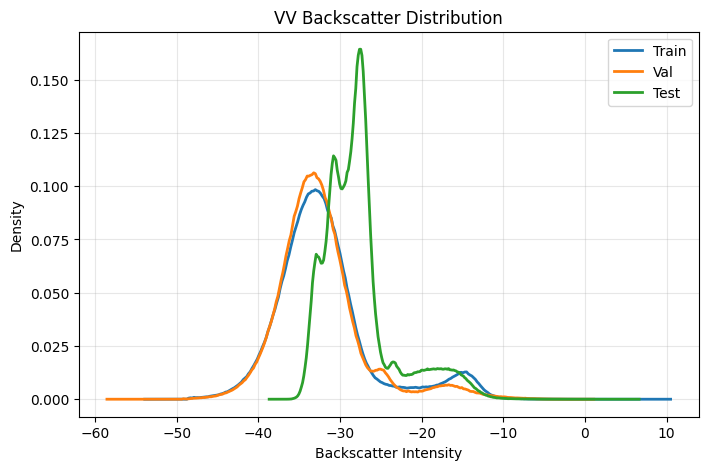

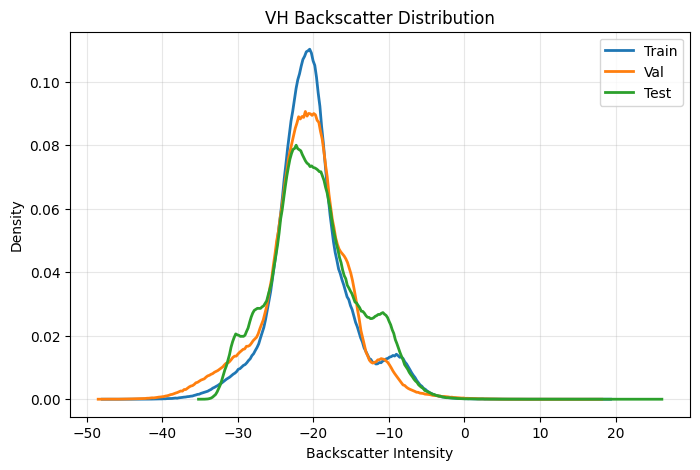

In [9]:
plot_band_distributions({"Train": train_vv, "Val": val_vv, "Test": test_vv}, "VV")
plot_band_distributions({"Train": train_vh, "Val": val_vh, "Test": test_vh}, "VH")

## Post‑Normalization Distribution Check

My designed pipeline for harmonizing the input data (images) and also respecting the expected input format by Satlas model:

- Clipping to [-50, 0] : because oil/water intensity is usually not larger than 0dB and the the dataset shows ignorable intensities smaller than -50. 
- Stretch and shift: Normalize by stretching between 0-1 and shift away from 0 by a small step (0.1) so that our important features (dark oil spills) won't loose their signal by being too close to zero.
- Handle no-data: This dataset doesn't have an explicit no-data in rasters (bad idea in general!). But, a first plotting without no-data handling showed that there are saturations at db=0, meaning 0 is actually used no-data.

If this normalization strategy is appropriate, we have to achieve:

- Similar-looking post‑normalization distributions across splits
- No saturation

In [10]:
no_data_norm = 1.2
def loader_from_paths(impaths, batch_size=1):
    ds = oilcls.OilSpillDataset(None, None, None, augment=False, input_size=input_size)
    ds.images, ds.classes = [], []
    for img_path in impaths:
        ds.images.append((img_path, torch.tensor([0],  dtype=torch.long))) 
        ds.classes.append(0)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return loader
    
def collect_normalized_pixels(sampled_paths=None, image_paths=None, max_images=60, max_pixels=50_000):
    vv_vals, vh_vals = [], []
    
    if sampled_paths is None:
        sampled_paths = random.sample(image_paths, min(max_images, len(image_paths)))

    loader = loader_from_paths(sampled_paths)
    with torch.no_grad():
        for imgs, _, _ in loader:
            img = imgs[0].detach().cpu().numpy()
            for b, container in zip([0, 1], [vh_vals, vv_vals]): #note we changed the order of bands in the Dataset
                flat = img[b].ravel()
                flat = flat[flat != no_data_norm]
                if flat.size > max_pixels:
                    flat = np.random.choice(flat, max_pixels, replace=False)
                container.append(flat)

    return sampled_paths, np.concatenate(vv_vals), np.concatenate(vh_vals)


In [11]:
_, tr_vv_n, tr_vh_n = collect_normalized_pixels(sampled_paths=train_sampled_paths)
_, va_vv_n, va_vh_n = collect_normalized_pixels(sampled_paths=val_sampled_paths)
_, te_vv_n, te_vh_n = collect_normalized_pixels(sampled_paths=test_sampled_paths)

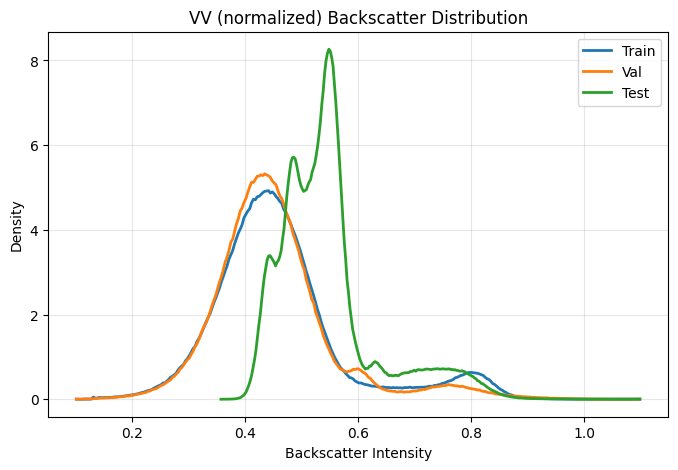

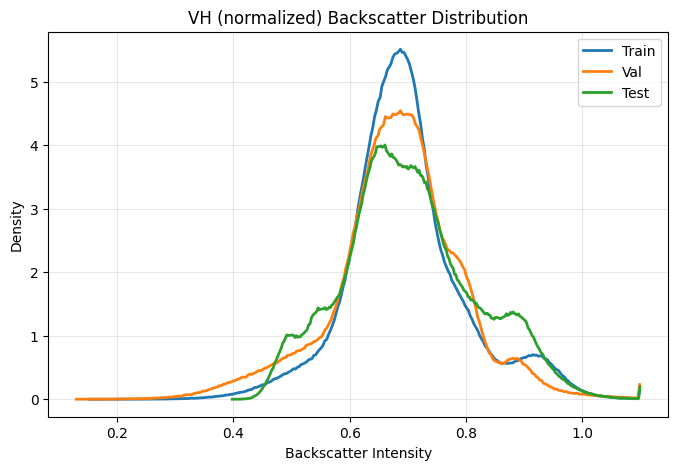

In [12]:
plot_band_distributions({"Train": tr_vv_n, "Val": va_vv_n, "Test": te_vv_n}, "VV (normalized)")
plot_band_distributions({"Train": tr_vh_n, "Val": va_vh_n, "Test": te_vh_n}, "VH (normalized)")

## Visual Sanity Check: Bands Before and After Normalization

To ensure that normalization:

- Preserves spatial structure
- Does not wash out oil slicks
- Does not introduce artificial contrast
- Behaves consistently across classes

We visualize:

- Few images per class (clean, oil, look‑alike)
    - Both polarizations (VV, VH)
    - Before normalization and after normalization

This helps catch:

- Over‑aggressive clipping/stretching
- Padding dominating the dynamic range
- Unexpected polarity inversions (VV ↔ VH)

In [13]:
def sample_one_per_class(split_dict, ext="tif"):
    samples = {}
    for key, folder in split_dict.items():
        if folder is None:
            continue
        paths = glob.glob(os.path.join(folder, f"*.{ext}"))
        if not paths:
            raise RuntimeError(f"No tif files in {folder}")
        samples[key.replace("images_dir_", "")] = random.choice(paths)
    return samples

def show_sample_normalized(samples, classes=['oil','lookalike','clean']):
    fig, axs = plt.subplots(len(classes), 2, figsize=(8, 10))
    for i, cls in enumerate(classes):
        loader = loader_from_paths([samples[cls]])
        with torch.no_grad():
            for imgs, _, _ in loader:
                img_normalized = imgs[0].detach().cpu().numpy()
        axs[i, 0].imshow(img_normalized[0], cmap="gray")
        axs[i, 1].imshow(img_normalized[1], cmap="gray")
        axs[i, 0].set_ylabel(cls, fontsize=12, rotation=0, labelpad=30, va="center")
        axs[i, 0].set_title("VH")
        axs[i, 1].set_title("VV")
        for j in range(2):
            axs[i, j].set_xticks([])
            axs[i, j].set_yticks([])
            axs[i, j].spines[:].set_visible(False)

        plt.suptitle('Normalized', fontsize=14)
    plt.tight_layout()
    plt.show()

def show_sample_raw(samples, classes=['oil','lookalike','clean']):
    fig, axs = plt.subplots(len(classes), 2, figsize=(8, 10))
    for i, cls in enumerate(classes):
        img_raw = read_sample(samples[cls])
        axs[i, 0].imshow(img_raw[1], cmap="gray")
        axs[i, 1].imshow(img_raw[0], cmap="gray")
        axs[i, 0].set_ylabel(cls, fontsize=12, rotation=0, labelpad=30, va="center")
        axs[i, 0].set_title("VH")
        axs[i, 1].set_title("VV")
        for j in range(2):
            axs[i, j].set_xticks([])
            axs[i, j].set_yticks([])
            axs[i, j].spines[:].set_visible(False)
    plt.suptitle('Raw', fontsize=14)
    plt.tight_layout()
    plt.show()

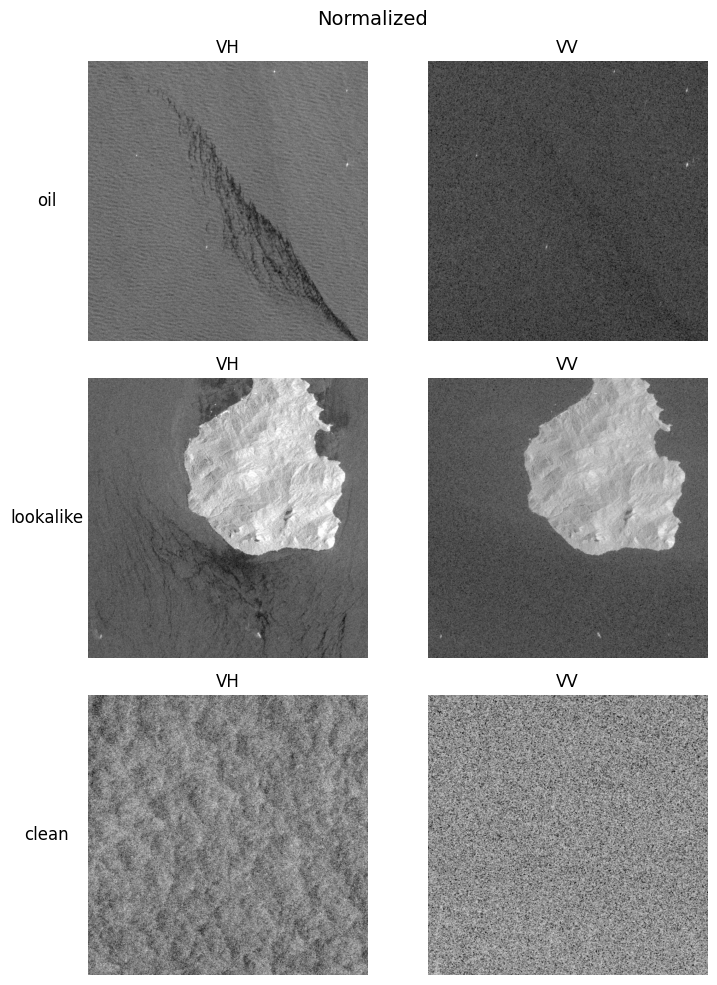

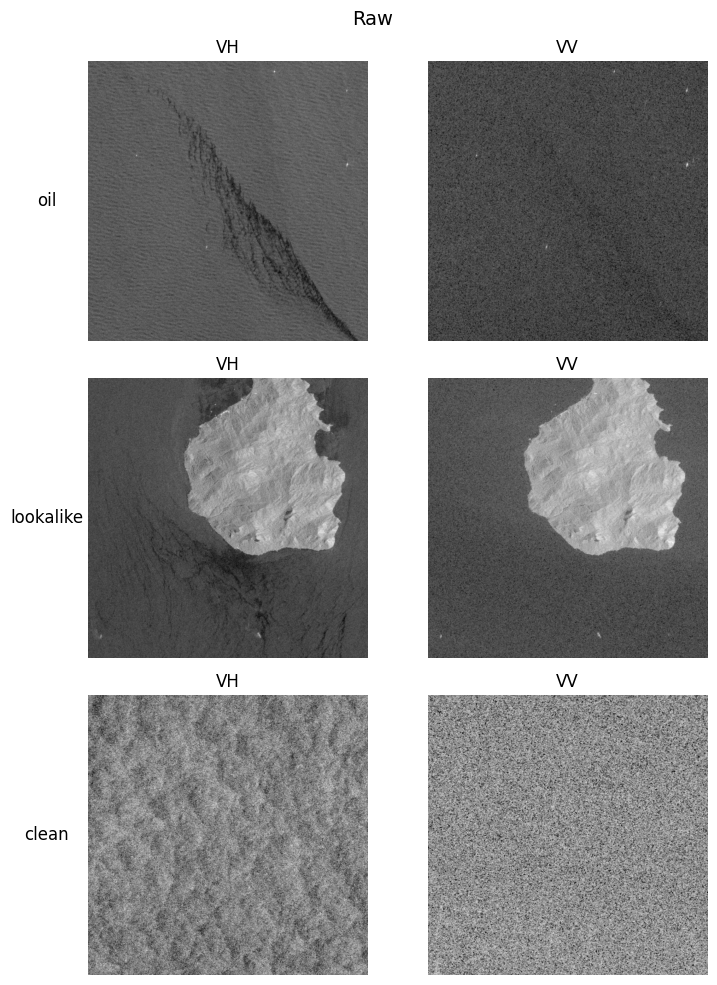

##############################################################################


In [14]:
sample_count = 1
for i in range(sample_count):
    samples = sample_one_per_class(train_df)
    show_sample_normalized(samples)
    show_sample_raw(samples)
    print("##############################################################################")

## Geospatial Distributon Check

This helps us with:

- spotting geographic leakage
- identifying regional bias
- validating split strategy
- understanding environment diversity (latitudinal clustering, coastal vs open ocean, etc.)

How? 
- Extract latitude / longitude from each GeoTIFF (we know they are geo-referenced with CRS EPSG:4326)
- Tag each point by split (train / val / test)
- Tag each point by class (oil / look‑alike / clean)
- Plot everything together in a single geospatial scatter plot
- Keep track of the dataframe for later saving it as a geopackage


In [15]:
def get_geotiff_center_latlon(tif_path):
    """
    Returns (lon, lat) of the center of a GeoTIFF in EPSG:4326.
    """
    with rasterio.open(tif_path) as src:
        h, w = src.height, src.width
        row = h // 2
        col = w // 2
        lon, lat = rio_xy(src.transform, row, col)
    return lon, lat


def collect_geospatial_metadata(split_df, split_name, ext="tif"):
    records = []

    for key, folder in split_df.items():
        if folder is None:
            continue

        class_name = key.replace("images_dir_", "")
        paths = glob.glob(os.path.join(folder, f"*.{ext}"))

        for p in tqdm(paths, desc=f"{split_name}-{class_name}"):
            lon, lat = get_geotiff_center_latlon(p)
            records.append({
                "lon": lon,
                "lat": lat,
                "split": split_name,
                "class": class_name,
                "path": p
            })

    return records


In [16]:
records = []
records += collect_geospatial_metadata(train_df, "train")
records += collect_geospatial_metadata(val_df, "val")
records += collect_geospatial_metadata(test_df, "test")

geo_df = pd.DataFrame(records)
geo_df.head()

test-clean: 100%|███████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 205.00it/s]


,lon,lat,split,class,path
0,5.171697,55.472979,train,oil,C:\Users\mshahbaz\Documents\oilspill\dataset\t...
1,29.241536,32.203378,train,oil,C:\Users\mshahbaz\Documents\oilspill\dataset\t...
2,30.977852,32.638985,train,oil,C:\Users\mshahbaz\Documents\oilspill\dataset\t...
3,49.158367,27.697023,train,oil,C:\Users\mshahbaz\Documents\oilspill\dataset\t...
4,54.353991,25.900180,train,oil,C:\Users\mshahbaz\Documents\oilspill\dataset\t...


In [17]:
def plot_geospatial_distribution_geopandas(df, splits):
    fig, ax = plt.subplots(figsize=(14, 7))

    world = gpd.read_file("./Pretrained/world/ne_110m_admin_0_countries.shp")
    world.plot(
        ax=ax,
        color="lightgray",
        edgecolor="black"
    )

    split_markers = {
        "train": "o",
        "val": "^",
        "test": "s"
    }

    class_colors = {
        "clean": "green",
        "oil": "red",
        "lookalike": "orange"
    }

    for split in splits:
        marker = split_markers[split]
        for cls, color in class_colors.items():
            subset = df[
                (df["split"] == split) &
                (df["class"] == cls)
            ]
    
            ax.scatter(
                subset["lon"],
                subset["lat"],
                marker=marker,
                color=color,
                s=10,
                alpha=0.7,
                label=f"{split}-{cls}"
            )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Geospatial Distribution of Samples - {splits}")
    ax.legend(ncol=3, fontsize=9)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    plt.tight_layout()
    plt.show()

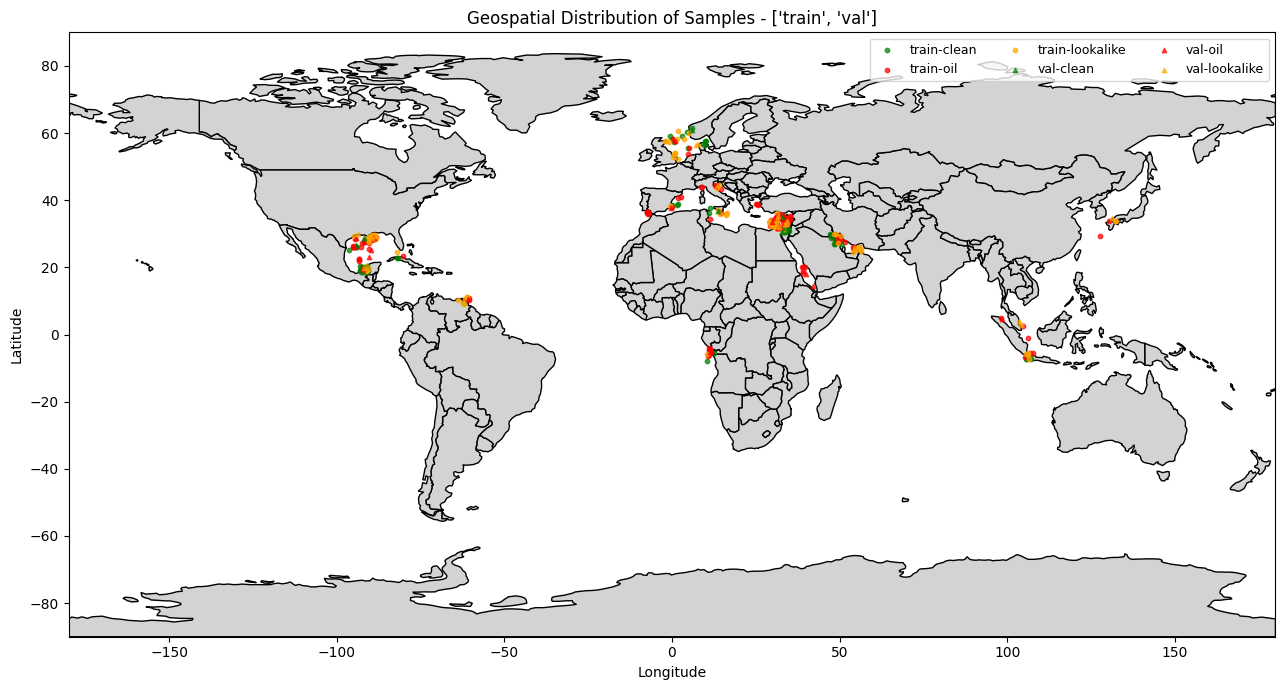

In [18]:
plot_geospatial_distribution_geopandas(geo_df, ["train", "val"])

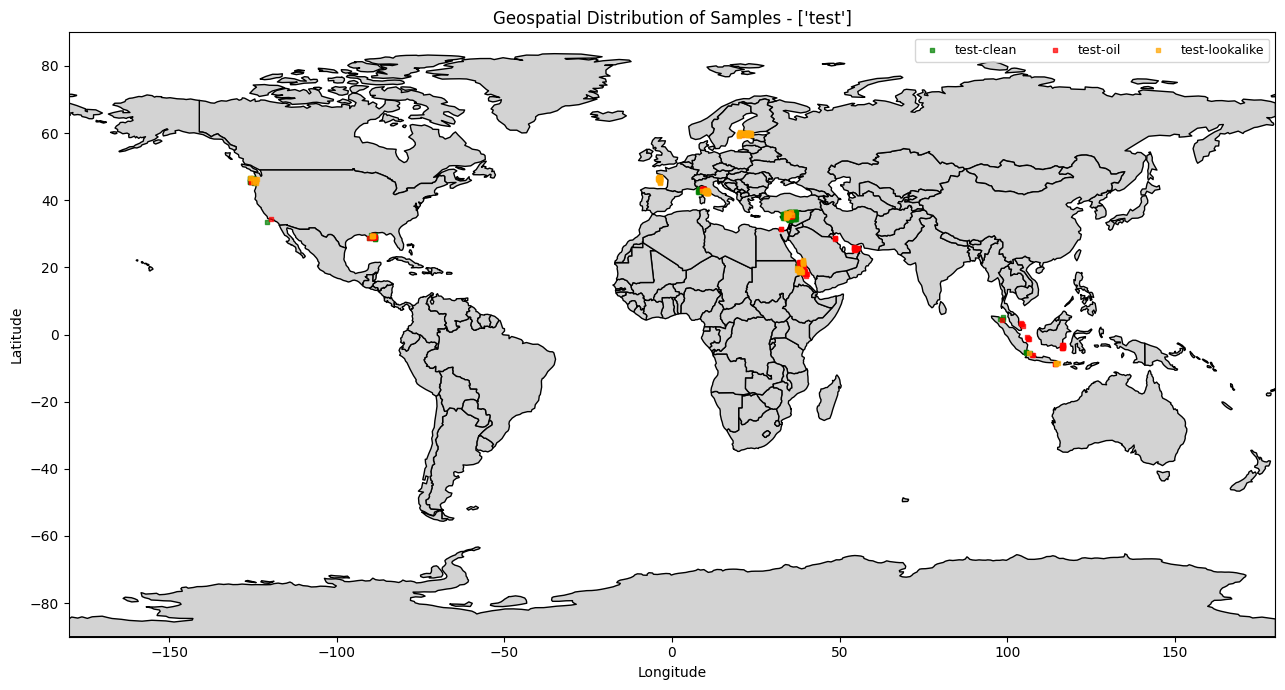

In [19]:
plot_geospatial_distribution_geopandas(geo_df, ["test"])

# Class Balance & Sampling Strategy

SAR oil spill dataset might be inherently imbalanced, e.g.:

- Clean ≫ Look‑alike ≫ Oil ?
- My weighted sampler acts only if clean & lookalike classes collectively have more samples than the oil class. 

In [20]:
def effective_sampling_distribution(loader):
    counts = Counter()
    for i, (_, labels, _) in enumerate(loader):
        counts.update(labels.detach().cpu().numpy().flatten().tolist())
    return counts

In [21]:
train_ds = oilcls.OilSpillDataset(train_df['images_dir_oil'], train_df['images_dir_lookalike'], train_df['images_dir_clean'], 
                                  augment=False, input_size=input_size, merge_clean_lookalike=merge_clean_lookalike)
sampler, class_counts, class_weights = train_ds.generate_sampler()
print("train class counts:", class_counts)
if sampler is not None:
    train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler, num_workers=0, pin_memory=True)
    print("train class weights for weighted sampling:", class_weights)
else:
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_ds = oilcls.OilSpillDataset(val_df['images_dir_oil'], val_df['images_dir_lookalike'], val_df['images_dir_clean'], 
                                augment=False, input_size=input_size, merge_clean_lookalike=merge_clean_lookalike)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
print("validation class counts:", Counter(val_ds.targets().tolist()))
test_ds = oilcls.OilSpillDataset(test_df['images_dir_oil'], test_df['images_dir_lookalike'], test_df['images_dir_clean'], 
                                 augment=False, input_size=input_size, merge_clean_lookalike=merge_clean_lookalike)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
print("test class counts:", Counter(test_ds.targets().tolist()))

train class counts: Counter({0: 176, 1: 155})
train class weights for weighted sampling: {1: 1.135483870967742, 0: 1.0}
validation class counts: Counter({0: 28, 1: 25})
test class counts: Counter({0: 300, 1: 150})


In [22]:
pre_counts = Counter(train_loader.dataset.targets())
pre_counts_keys = list(pre_counts.keys())
pre_counts_keys.sort()
pre_counter = [pre_counts[key] for key in pre_counts_keys]
print(pre_counter)

[176, 155]


In [23]:
post_counts = effective_sampling_distribution(train_loader)
post_counts_keys = list(post_counts.keys())
post_counts_keys.sort()
post_counter = [post_counts[key] for key in post_counts_keys]
print(post_counter)

[160, 171]


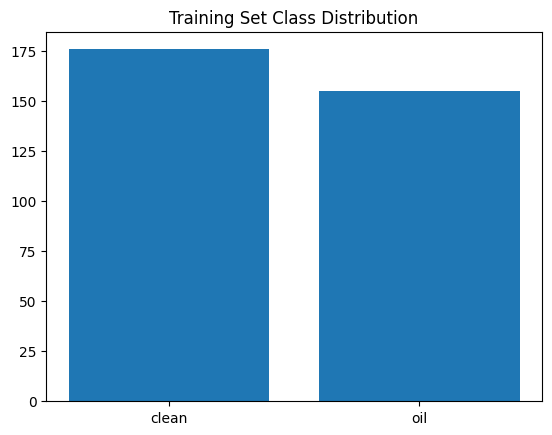

In [24]:
plt.bar(class_names, pre_counter)
plt.title("Training Set Class Distribution")
plt.show()

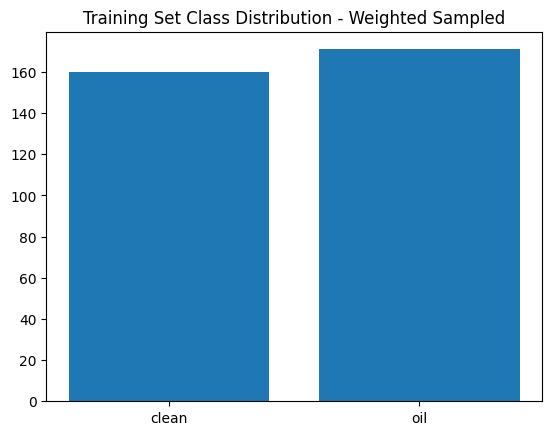

In [25]:
plt.bar(class_names, post_counter)
plt.title("Training Set Class Distribution - Weighted Sampled")
plt.show()

# Encoder Feature Space Exploration (Satlas Pretrain)

I want to understand the challenges of this classification task:
- Is the information needed to classify my classes already present in the encoder features, without learning new representations?
- Do oil spills separate at all in pretrained Satlas space?
- Is training a classification head likely to succeed or I would need representation fine-tuning too?

### How?

- Extract encoder features (1024-dimensional)
- Train a linear probe to see if the essential information already exist in the embeddings
- Check whether such classifer works well on val/test data too (pre-determining risks of over-fitting)

In [26]:
model = oilcls.SatlasClassifier(freeze_backbone=True, num_classes=num_classes).to(device)
model.eval()

SatlasClassifier(
  (backbone): Model(
    (backbone): SwinBackbone(
      (backbone): SwinTransformer(
        (features): Sequential(
          (0): Sequential(
            (0): Conv2d(2, 128, kernel_size=(4, 4), stride=(4, 4))
            (1): Permute()
            (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          )
          (1): Sequential(
            (0): SwinTransformerBlockV2(
              (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attn): ShiftedWindowAttentionV2(
                (qkv): Linear(in_features=128, out_features=384, bias=True)
                (proj): Linear(in_features=128, out_features=128, bias=True)
                (cpb_mlp): Sequential(
                  (0): Linear(in_features=2, out_features=512, bias=True)
                  (1): ReLU(inplace=True)
                  (2): Linear(in_features=512, out_features=4, bias=False)
                )
              )
              (stochastic_depth): StochasticDepth(

In [27]:
def extract_features(loader):
    feats_all, labels_all, paths_all = [], [], []
    with torch.no_grad():
        for i, (imgs, labels, paths) in enumerate(loader):
            imgs = imgs.to(device)
            feats = model.extract_encoder_feats(imgs)
            feats_all.append(feats.detach().cpu().numpy())
            if len(labels.shape) == 2:
                labels = labels.squeeze(1)
            labels_all.append(labels.detach().cpu().numpy())
            paths_all.extend(paths)
    return np.vstack(feats_all), np.concatenate(labels_all), paths_all

In [28]:
X_train, y_train, paths_all_train = extract_features(train_loader)
y_cls_names_train = [class_names[yi] for yi in y_train]
X_val, y_val, paths_all_val = extract_features(val_loader)
y_cls_names_val = [class_names[yi] for yi in y_val]
X_test, y_test, paths_all_test = extract_features(test_loader)
y_cls_names_test = [class_names[yi] for yi in y_test]
print(f"X-train shape:{X_train.shape}")
print(f"y-train shape:{y_train.shape}")
print(f"X-val shape:{X_val.shape}")
print(f"y-val shape:{y_val.shape}")
print(f"X-test shape:{X_test.shape}")
print(f"y-test shape:{y_test.shape}")

X-train shape:(331, 1024)
y-train shape:(331,)
X-val shape:(53, 1024)
y-val shape:(53,)
X-test shape:(450, 1024)
y-test shape:(450,)


## Linear Probe

If a linear classifier works well, then:

- The representation is adequately good

If it fails:

- The representation does not separate classes well yet
- End‑to‑end (including the encoder) fine‑tuning is necessary

The random chance of succeeding is ~0.33 for three-way setting and ~0.5 for binary classification; so:

- Linear probe accuracy of < 0.5 → Encoder features do not separate classes
- Linear probe accuracy of 0.50–0.80  →  Strong separability
- Linear probe accuracy of larger than 0.80  →  Excellent :)

In [29]:
clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1
)

cvstr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_train, y_train, cv=cvstr, scoring="accuracy", n_jobs=-1)

print(f"Linear probe accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

Linear probe accuracy: 0.891 ± 0.044


In [30]:
clf.fit(X_train, y_train)
y_pred_linear = clf.predict(X_train)

print("Linear classification metrics for train dataset:")
print(classification_report(y_train, y_pred_linear, target_names=class_names))


Linear classification metrics for train dataset:
              precision    recall  f1-score   support

       clean       0.99      1.00      0.99       155
         oil       1.00      0.99      0.99       176

    accuracy                           0.99       331
   macro avg       0.99      0.99      0.99       331
weighted avg       0.99      0.99      0.99       331



## Testing Overfitting Chances

Check how the trained classifier performs on val/test:

- Train ≫ Val/Test → real domain shifts

- Train ≈ Val/Test → healthy pipeline

- All accuries > 0.5 → strong starting point

In [31]:
val_y_pred_linear = clf.predict(X_val)

print("Linear classification metrics for validation dataset:")
print(classification_report(y_val, val_y_pred_linear, target_names=class_names))


Linear classification metrics for validation dataset:
              precision    recall  f1-score   support

       clean       0.91      0.75      0.82        28
         oil       0.77      0.92      0.84        25

    accuracy                           0.83        53
   macro avg       0.84      0.83      0.83        53
weighted avg       0.84      0.83      0.83        53



In [32]:
test_y_pred_linear = clf.predict(X_test)

print("Linear classification metrics for test dataset:")
print(classification_report(y_test, test_y_pred_linear, target_names=class_names))

Linear classification metrics for test dataset:
              precision    recall  f1-score   support

       clean       0.86      0.85      0.86       300
         oil       0.71      0.73      0.72       150

    accuracy                           0.81       450
   macro avg       0.79      0.79      0.79       450
weighted avg       0.81      0.81      0.81       450



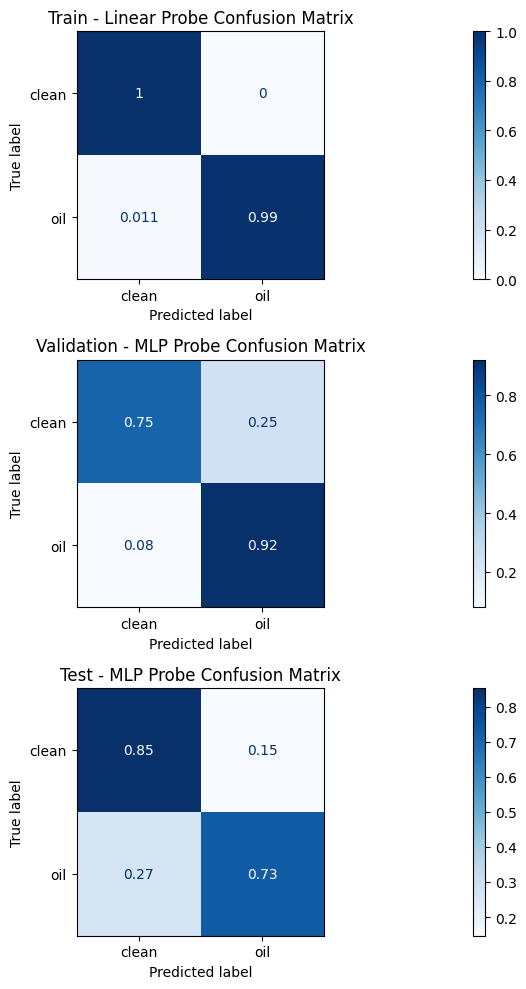

In [33]:
ig, axes = plt.subplots(3, 1, figsize=(30, 10))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_linear,
    display_labels=class_names,
    cmap="Blues",
    ax=axes[0],
    normalize="true"
)
axes[0].set_title("Train - Linear Probe Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_y_pred_linear,
    display_labels=class_names,
    cmap="Blues",
    ax=axes[1],
    normalize="true"
)
axes[1].set_title("Validation - MLP Probe Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_y_pred_linear,
    display_labels=class_names,
    cmap="Blues",
    ax=axes[2],
    normalize="true"
)
axes[2].set_title("Test - MLP Probe Confusion Matrix")
plt.tight_layout()
plt.show()


### Let's save the predictions in geopackage format for bette geospatial investigations in a GIS environment

In [34]:
def make_pred_df(paths, y_true, y_lin):
    return pd.DataFrame({
        "path": paths,
        "prediction": y_lin,
        "pred_correct": y_lin == y_true,
    })


In [35]:
pred_train = make_pred_df(paths_all_train, y_train, y_pred_linear)
pred_val = make_pred_df(paths_all_val, y_val, val_y_pred_linear)
pred_test = make_pred_df(paths_all_test, y_test, test_y_pred_linear)

pred_all = pd.concat(
    [pred_train, pred_val, pred_test],
    axis=0,
    ignore_index=True
)
# if we had a weighted sampler involve, some paths might be repeated multiple times
pred_all = (
    pred_all
    .groupby("path", as_index=False)
    .first()
)

In [36]:
geo_df = geo_df.merge(
    pred_all,
    on="path",
    how="left",
    validate="one_to_one"
)

# How many samples have predictions?
print(geo_df[["prediction"]].notna().mean())

# Spot check
geo_df.sample(5)[["split", "class", "prediction"]]


prediction    0.859712
dtype: float64


,split,class,prediction
181,train,lookalike,NaN
604,test,lookalike,0.0
416,test,oil,1.0
276,train,clean,0.0
83,train,oil,1.0


In [37]:
gdf = gpd.GeoDataFrame(
    geo_df,
    geometry=[Point(xy) for xy in zip(geo_df.lon, geo_df.lat)],
    crs="EPSG:4326"
)

for split in ["train", "val", "test"]:
    gdf[gdf["split"] == split].to_file(
        gpkg_path,
        layer=split,
        driver="GPKG"
)


## Exercise 1

Visualize misclassified samples geographically and identify spatial patterns associated with errors.

How to do this?

- Filter misclassified samples
- Plot them on the map
- Compare error locations with:
    - coastlines
    - regions with dense shipping
    - regions absent from training data

Do you see if:
- Errors cluster spatially?
- Generalization failure often maps to geography

## Exercise 2

Compare the same experiments but with a RESNET18 model pretrained on ImageNet dataset.

How to do this?

- Repeat everything but with oilcls.ResNet18Classifier model (already defined for you).

What to expect?
- I believe the train accuracies will be high (because it is a very small dataset and we easily overfit to it) but on the test dataset, I expect that the accuracy be lower than 50% (close to random guessing basically).

## Exercise 3
I prepared all the functions essential to train either of the Satlas-based or Resnet-based models. Let's try training the model.

Additionally, I provided functionalities to draw class-specific activation maps (CAMs) when you infer from a dataset. 

CAMs are kind of hotspot maps that point out to the "spatial" importance of the features that contributed to the classification decision. In this dataset, for the images classified by the model as "oil", they should roughly show peaks around the oil slicks/spills. 

Here is an example of an image with oil slick, and CAM dervied form my Satlas-based classifier:

![](./Assets/cam_presentation.png)
